<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Explicabilidad de Modelos: Atribución de Variables e Interpretabilidad 🔍
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Machine Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 08
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Machine%20Learning/08%20-%20Temas%20Avanzados%20de%20ML/02_Explicabilidad_de_Modelos.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Objetivos de Aprendizaje 🔎

Este cuaderno desarrolla la **Sección 3.5** del libro (*Model explainability: feature attribution, interpretability approaches*). Un modelo que acierta pero **no se puede cuestionar** es difícil de depurar, de auditar y de defender ante quien sufre sus decisiones. Aquí estudiamos cómo **preguntarle a un modelo por qué predijo lo que predijo**, pero con una advertencia constante: **una explicación es otro modelo** (con sus supuestos, su costo y sus trampas) y **no es una prueba de causalidad**. Siguiendo el estilo del curso, implementamos las técnicas **desde cero**, las **verificamos con `assert`** (contra `scikit-learn`, contra fórmulas cerradas y contra `shap` si está instalado) y probamos sus **límites**.

Al terminar podrás:

1. **Clasificar** un método de explicación como **intrínseco o *post-hoc***, **global o local**, **agnóstico o específico del modelo**.
2. **Implementar PDP e ICE desde cero** (verificados contra `sklearn.inspection.partial_dependence`) y **explicar** por qué las variables correlacionadas los vuelven engañosos.
3. **Calcular valores de Shapley exactos desde cero** (enumerando coaliciones) y **verificar con `assert`** las propiedades de **eficiencia, jugador nulo, simetría y aditividad**; contrastarlos con `shap` (opcional).
4. **Implementar LIME desde cero** (modelo lineal local ponderado por un núcleo), validarlo con un modelo lineal y **medir su inestabilidad**.
5. **Implementar *gradiente × entrada* y gradientes integrados** con PyTorch, verificando el **axioma de completitud** $\sum_i \text{IG}_i=f(\mathbf x)-f(\mathbf x')$.
6. **Reconocer las trampas**: explicación $\neq$ causalidad, crédito repartido entre variables correlacionadas, explicaciones que **discrepan** entre modelos igual de buenos y **modelos injustos «explicables»**.
7. **Elegir la técnica adecuada** con una tabla guía y **relacionarla con la regulación y la ética**.

> 📍 **Dónde estamos:** Módulo 08, cuaderno 3 de 5. Venimos de [Transfer Learning y *Fine-Tuning*](01_Transfer_Learning_y_Fine_Tuning.ipynb). Siguientes: [Datasets desbalanceados](03_Datasets_Desbalanceados.ipynb) → [Datos faltantes](04_Datos_Faltantes.ipynb).

> 🔗 **Para no repetir:** la importancia de variables **MDI frente a permutación** (con su implementación a mano) se estudia en el [Módulo 02, cuaderno 01](../02%20-%20Arboles%20Bosques%20y%20Redes%20Neuronales/01_Random_Forests.ipynb); aquí la **usamos como punto de comparación** y profundizamos con otras técnicas. La ética de la IA (sesgo, transparencia, responsabilidad) está en [IA, Módulo 03](../../Introduccion%20a%20la%20Inteligencia%20Artificial/03%20-%20Etica%20y%20el%20Nuevo%20Paradigma%20de%20la%20IA/README.md); aquí se aborda el lado **técnico**.

---
## Recursos Recomendados 📚

### 📖 Libros de Referencia:
- *Ensemble Methods for Machine Learning* — **Gautam Kunapuli** (Manning). Cap. 9 (*Explaining your ensembles*): 9.1 *What is interpretability?* (*Black-box vs. glass-box models*), 9.3 *Black-box methods for global explainability* (*Permutation feature importance*, *Partial dependence plots*, *Global surrogate models*), 9.4 *Black-box methods for local explainability* (*Local surrogate models with LIME*, *Local interpretability with SHAP*) y 9.5 *Glass-box ensembles* (*Explainable boosting machines*) (disponible en `Machine Learning/Libros/`; verificado contra el índice del PDF).
- *Fundamentals of Robust Machine Learning* — **Resve Saleh**. Cap. 12, sección 12.4 (*Application to Explainable Artificial Intelligence (XAI)*) (disponible en `Machine Learning/Libros/`; verificado contra el índice del PDF).
- *Hands-On Machine Learning with Scikit-Learn and PyTorch* — **Aurélien Géron** (O'Reilly, 2025). Cap. 2, sección *Analyzing the Best Models and Their Errors* (importancia de variables y análisis de errores) (disponible en `Machine Learning/Libros/`; título verificado contra el índice del PDF).
- Molnar, C., *Interpretable Machine Learning* (libro en línea de acceso libre): PDP, ICE, LIME, Shapley y SHAP *(citado de memoria, verificar)*.
- Shapley, L. S. (1953), *A value for n-person games*, en **Contributions to the Theory of Games II** · Lundberg, S. M. & Lee, S.-I. (2017), *A unified approach to interpreting model predictions*, **NeurIPS 30** · Štrumbelj, E. & Kononenko, I. (2014), *Explaining prediction models and individual predictions with feature contributions*, **Knowledge and Information Systems** 41 *(citados de memoria, verificar)*.
- Ribeiro, M. T., Singh, S. & Guestrin, C. (2016), *«Why should I trust you?»: explaining the predictions of any classifier*, **KDD** (LIME) *(citado de memoria, verificar)*.
- Sundararajan, M., Taly, A. & Yan, Q. (2017), *Axiomatic attribution for deep networks*, **ICML** (gradientes integrados) *(citado de memoria, verificar)*.
- Friedman, J. H. (2001), *Greedy function approximation: a gradient boosting machine*, **Annals of Statistics** 29(5) (PDP) · Goldstein, A., Kapelner, A., Bleich, J. & Pitkin, E. (2015), *Peeking inside the black box: visualizing statistical learning with plots of individual conditional expectation*, **JCGS** 24(1) (ICE) · Apley, D. W. & Zhu, J. (2020), *Visualizing the effects of predictor variables in black box supervised learning models*, **JRSS-B** 82(4) (ALE) *(citados de memoria, verificar)*.
- Rudin, C. (2019), *Stop explaining black box models for high stakes decisions and use interpretable models instead*, **Nature Machine Intelligence** 1: 206–215 · Kumar, I. E., Venkatasubramanian, S., Scheidegger, C. & Friedler, S. (2020), *Problems with Shapley-value-based explanations as feature importance measures*, **ICML** · Lipton, Z. C. (2018), *The mythos of model interpretability*, **Queue** 16(3) *(citados de memoria, verificar)*.

### 🌐 Documentación y Recursos Online:
- [scikit-learn: Partial Dependence and ICE](https://scikit-learn.org/stable/modules/partial_dependence.html) · [Permutation feature importance](https://scikit-learn.org/stable/modules/permutation_importance.html)
- [SHAP (documentación)](https://shap.readthedocs.io/) *(opcional: `pip install shap`)* · [PyTorch `autograd`](https://pytorch.org/docs/stable/autograd.html)

---
## 1. Taxonomía: Qué Significa «Explicar» un Modelo 🧭

### 1.1 Para qué explicar

Se explica para **(a) depurar** (¿usa un atajo espurio? Módulo 08, cuaderno 00), **(b) ganar y justificar confianza**, **(c) auditar** equidad y cumplimiento, **(d) obtener conocimiento** del fenómeno (con cuidado) y **(e) cumplir exigencias legales o de gestión** de decisiones automatizadas. Ninguna de ellas exige que la explicación sea una **prueba de causalidad**, y de hecho **no lo es**: explica **cómo el modelo usa las variables**, no cómo funciona el mundo.

### 1.2 Tres ejes para clasificar un método

| Eje | Opciones | Significado |
|---|---|---|
| **¿Cuándo?** | **Intrínseca** (modelo interpretable por diseño) · ***post-hoc*** (se explica un modelo ya entrenado) | Un modelo lineal o un árbol pequeño **es** su propia explicación; una red o un bosque necesitan un **explicador** externo |
| **¿Qué alcance?** | **Global** (cómo funciona **en general**) · **local** (por qué **esta** predicción) | Importancia por permutación o PDP son globales; LIME, SHAP por instancia y gradientes integrados son locales |
| **¿Qué supone del modelo?** | **Agnóstica** (solo usa `predict`) · **específica** (usa su estructura: gradientes, árboles) | Permutación, PDP, Shapley por enumeración y LIME son agnósticos; TreeSHAP y los gradientes integrados son específicos |

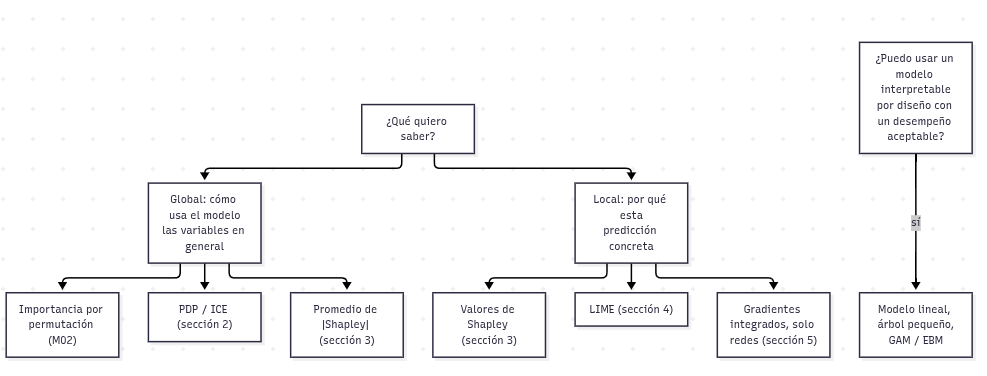

> 🎯 **Una advertencia desde el inicio** (Rudin, 2019; Lipton, 2018): en decisiones de **alto riesgo** (salud, justicia, crédito), cuando un modelo interpretable por diseño rinde casi igual, es preferible a **explicar a posteriori** una caja negra: la explicación *post-hoc* es una **aproximación** que puede ser **infiel** al modelo.

In [ ]:
# ============================================================
# Configuracion inicial
# ============================================================
# !pip install -q numpy pandas matplotlib seaborn scikit-learn scipy torch
# !pip install -q shap          # OPCIONAL: solo para la verificacion contra la libreria shap

import math
import time
import warnings
warnings.filterwarnings("ignore")                        # antes de importar shap/torch (algunas librerias avisan al importarse)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn
from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.inspection import partial_dependence, permutation_importance

try:                                                   # shap es OPCIONAL: sin el, solo se omiten las verificaciones contra la libreria
    import shap
except Exception:
    shap = None
try:                                                   # PyTorch solo se usa en la seccion 5 (gradientes integrados)
    import torch
    import torch.nn as nn
except Exception:
    torch = None

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
PALETA = ["#2563eb", "#dc2626", "#16a34a", "#f59e0b", "#7c3aed", "#0891b2", "#db2777", "#65a30d", "#78350f", "#475569"]
print(f"Entorno listo | numpy {np.__version__} | scipy {scipy.__version__} | scikit-learn {sklearn.__version__}")
print(f"shap: {'instalado ' + shap.__version__ if shap else 'NO instalado (opcional)'} | torch: {torch.__version__ if torch else 'NO instalado (necesario en la sección 5)'}")

---
## 2. PDP e ICE: la Forma del Efecto de una Variable 📈

### 2.1 Definiciones

Sea $\hat f$ el modelo y $S$ el conjunto de variables de interés (casi siempre una sola, $x_j$). La **dependencia parcial** (*partial dependence plot*, Friedman, 2001) promedia las predicciones **fijando $x_S$ y dejando que el resto $x_C$ recorra los datos**:

$$\text{PD}_S(\mathbf{x}_S)=\mathbb E_{\mathbf X_C}\big[\hat f(\mathbf x_S,\mathbf X_C)\big]\;\approx\;\frac1n\sum_{i=1}^{n}\hat f\big(\mathbf x_S,\mathbf x_C^{(i)}\big).$$

La **expectativa condicional individual** (*ICE*, Goldstein et al., 2015) **no promedia**: dibuja **una curva por ejemplo**, $\hat f(\mathbf x_S,\mathbf x_C^{(i)})$ como función de $x_S$. El PDP es **el promedio de las curvas ICE**. Si las curvas ICE **no son paralelas**, el efecto **depende de otras variables** (hay **interacciones**) y el PDP **oculta** esa heterogeneidad: por eso conviene ver ambos.

### 2.2 El supuesto escondido y su costo

El promedio sobre $\mathbf X_C$ usa la **distribución marginal** de las demás variables, es decir, **supone que $x_S$ es independiente de $\mathbf x_C$**. Si no lo es, al fijar $x_S=v$ se combinan valores de $\mathbf x_C$ que **nunca** aparecen junto a $v$ en la realidad, y el modelo se evalúa en regiones **sin datos** (donde su comportamiento **es arbitrario**). Es la advertencia central sobre PDP (y sobre Shapley con esperanza marginal, sección 3). La alternativa más fiel es **ALE** (*accumulated local effects*, Apley y Zhu, 2020), que no desarrollamos aquí.

### 2.3 Qué hacemos

Implementamos ICE y PDP **desde cero** (un bucle sobre la rejilla) y los **verificamos contra** `sklearn.inspection.partial_dependence` con `method="brute"` y la **misma rejilla**, sobre un *Gradient Boosting* para el conjunto *Diabetes* (442 pacientes, 10 variables ya estandarizadas, objetivo = progresión de la enfermedad). Luego provocamos el problema de la correlación con un ejemplo donde **sabemos** que $x_2$ **no tiene efecto** sobre $y$.

In [ ]:
# ============================================================
# 2. PDP e ICE desde cero == sklearn.inspection.partial_dependence (modelo: Gradient Boosting sobre Diabetes)
# ============================================================
diab = load_diabetes()
X, y = diab.data, diab.target
nombres = list(diab.feature_names)                      # age, sex, bmi, bp, s1..s6 (ya estandarizadas)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=SEED)
gb = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=SEED).fit(Xtr, ytr)
print(f"Gradient Boosting sobre Diabetes: R² en prueba = {gb.score(Xte, yte):.3f}  (modelo modesto: el problema es ruidoso; sirve para explicar)")


def curvas_ice(modelo, X, j, rejilla):
    """ICE: para cada valor v de la rejilla, fija x_j = v en TODAS las filas y predice. Devuelve (n, len(rejilla))."""
    out = np.empty((len(X), len(rejilla)))
    for k, v in enumerate(rejilla):
        Xk = X.copy()
        Xk[:, j] = v
        out[:, k] = modelo.predict(Xk)
    return out


# --- Verificacion contra scikit-learn (misma rejilla, metodo 'brute') ---
j = nombres.index("bmi")
ref = partial_dependence(gb, Xtr, [j], kind="both", method="brute", grid_resolution=20)
rejilla = ref.get("grid_values", ref.get("values"))[0]                 # 'grid_values' (sklearn >= 1.3); 'values' en versiones antiguas
ice = curvas_ice(gb, Xtr, j, rejilla)
pdp = ice.mean(axis=0)                                                 # el PDP es el PROMEDIO de las curvas ICE
assert np.allclose(ice, ref["individual"][0]) and np.allclose(pdp, ref["average"][0])
print(f"ICE y PDP desde cero == sklearn (diferencia máxima ICE: {np.abs(ice - ref['individual'][0]).max():.1e}; PDP: {np.abs(pdp - ref['average'][0]).max():.1e}).")

# --- ICE + PDP para dos variables: bmi y s5 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, var in zip(axes, ["bmi", "s5"]):
    jj = nombres.index(var)
    g = np.linspace(np.percentile(Xtr[:, jj], 2), np.percentile(Xtr[:, jj], 98), 30)
    I = curvas_ice(gb, Xtr, jj, g)
    for fila in I[np.random.default_rng(0).choice(len(I), 60, replace=False)]:
        ax.plot(g, fila, color="#93c5fd", lw=0.8, alpha=0.7)
    ax.plot(g, I.mean(axis=0), color="#dc2626", lw=3, label="PDP (promedio de las ICE)")
    ax.set_xlabel(f"{var} (estandarizada)"); ax.set_ylabel("Predicción: progresión de la enfermedad"); ax.legend(fontsize=8)
    ax.set_title(f"ICE (60 pacientes) y PDP de {var}", fontweight="bold")
plt.tight_layout(); plt.show()
amplitud = {v: np.ptp(curvas_ice(gb, Xtr, nombres.index(v), np.linspace(np.percentile(Xtr[:, nombres.index(v)], 5), np.percentile(Xtr[:, nombres.index(v)], 95), 15)).mean(axis=0)) for v in nombres}
print("Amplitud del PDP (rango de la predicción media) por variable:", {k: round(float(v), 1) for k, v in sorted(amplitud.items(), key=lambda t: -t[1])[:5]}, "...")
assert amplitud["bmi"] > amplitud["age"] and amplitud["s5"] > amplitud["sex"]

# ============================================================
# 2b. El supuesto de independencia: x2 es una COPIA RUIDOSA de x1 y y NO depende de x2
# ============================================================
rng = np.random.default_rng(SEED)
n = 1500
x1 = rng.normal(0, 1, n)
x2 = x1 + 0.15 * rng.normal(0, 1, n)                   # corr(x1, x2) ~ 0.99
yy = x1 + 0.3 * rng.normal(0, 1, n)                    # SOLO x1 causa y (por construccion)
XX = np.column_stack([x1, x2])
m = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=SEED).fit(XX, yy)
print(f"\ncorr(x1, x2) = {np.corrcoef(x1, x2)[0, 1]:.3f}")
rangos, pi = {}, permutation_importance(m, XX, yy, n_repeats=10, random_state=SEED).importances_mean
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for k, (nom, c) in enumerate([("x1", PALETA[0]), ("x2", PALETA[1])]):
    g = np.linspace(np.percentile(XX[:, k], 3), np.percentile(XX[:, k], 97), 25)
    pdp_k = curvas_ice(m, XX, k, g).mean(axis=0)
    rangos[nom] = np.ptp(pdp_k)
    axes[0].plot(g, pdp_k, color=c, lw=2.5, label=f"PDP de {nom}")
axes[0].set_xlabel("valor de la variable"); axes[0].set_ylabel("predicción media"); axes[0].legend()
axes[0].set_title("x2 «parece» tener efecto aunque y no depende de ella", fontweight="bold", fontsize=9)
axes[1].scatter(x1, x2, s=5, color="#94a3b8", alpha=0.5, label="datos reales")
gv = np.linspace(-2, 2, 5)
for v in gv:                                            # los puntos EVALUADOS por el PDP de x1: x1 = v y x2 recorre TODA su marginal
    axes[1].scatter(np.full(60, v), np.random.default_rng(1).choice(x2, 60), s=10, color=PALETA[1], alpha=0.6, label="evaluados por el PDP de x1" if v == gv[0] else None)
axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel("$x_2$"); axes[1].legend(fontsize=8)
axes[1].set_title("El PDP evalúa el modelo en regiones SIN datos", fontweight="bold", fontsize=9)
axes[2].bar(["x1", "x2"], pi, color=[PALETA[0], PALETA[1]]); axes[2].set_ylabel("Importancia por permutación")
axes[2].set_title("Permutación: x2 también recibe crédito", fontweight="bold", fontsize=9)
plt.tight_layout(); plt.show()
print(f"Rango del PDP: x1 = {rangos['x1']:.2f}, x2 = {rangos['x2']:.2f} (¡y NO depende de x2!). Permutación: x1 = {pi[0]:.2f}, x2 = {pi[1]:.2f}.")
assert rangos["x2"] > 0.1 * rangos["x1"]               # el modelo reparte parte de su uso entre las dos copias: el PDP de x2 NO es cero

---
**Lectura de PDP e ICE.** Nuestro bucle de seis líneas reproduce `partial_dependence` **exactamente**: el PDP **es** el promedio de las curvas ICE. En *Diabetes*, el IMC (`bmi`) y `s5` (relacionada con triglicéridos, según la documentación del conjunto) elevan la progresión media, y las curvas ICE muestran **cuánto varía** ese efecto entre pacientes. En el ejemplo **correlacionado**, $y$ **no depende** de $x_2$ y aun así su PDP **no es plano**: como $x_2$ casi duplica a $x_1$, el modelo **repartió** su uso entre ambas, y el PDP de $x_2$ refleja **cómo el modelo la usa**, no un efecto real; además, el PDP de $x_1$ evalúa el modelo con combinaciones $(x_1,x_2)$ **imposibles** (los puntos rojos fuera de la diagonal de datos). **Un PDP describe al modelo, no al mundo**, y su supuesto de independencia debe revisarse antes de interpretarlo.

---

## 3. Valores de Shapley: Atribución con Garantías 🧮

### 3.1 Del reparto de ganancias a la atribución de predicciones

En teoría de juegos cooperativos (Shapley, 1953), un conjunto $N=\{1,\dots,M\}$ de **jugadores** genera una ganancia $v(S)$ según qué coalición $S\subseteq N$ participa. El **valor de Shapley** reparte la ganancia total entre los jugadores según su **contribución marginal promedio** sobre **todos los órdenes** posibles de llegada:

$$\varphi_j(v)=\sum_{S\subseteq N\setminus\{j\}}\frac{|S|!\,(M-|S|-1)!}{M!}\Big[v(S\cup\{j\})-v(S)\Big].$$

Para **explicar la predicción** de un modelo $f$ en una instancia $\mathbf x$, los **jugadores son las variables** y la ganancia es la predicción. Lo delicado es definir $v(S)$: **¿qué hace el modelo con las variables que NO están en $S$?** La definición habitual (**esperanza marginal**, Lundberg y Lee, 2017, en su variante *interventional*) las **sustituye por valores de un conjunto de referencia** (*fondo*, $B$ filas):

$$v_{\mathbf x}(S)=\frac1{|B|}\sum_{\mathbf b\in B}f\big(\mathbf x_S,\mathbf b_{N\setminus S}\big),\qquad v_{\mathbf x}(\emptyset)=\mathbb E_{\mathbf b}[f(\mathbf b)],\qquad v_{\mathbf x}(N)=f(\mathbf x).$$

### 3.2 Las propiedades (los axiomas) que lo justifican

| Propiedad | Enunciado | Qué evitamos con ella |
|---|---|---|
| **Eficiencia** | $\sum_j\varphi_j=f(\mathbf x)-\mathbb E_{\mathbf b}[f(\mathbf b)]$ | Atribuciones que **no suman** la predicción |
| **Jugador nulo** | Si $v(S\cup\{j\})=v(S)$ para todo $S$, entonces $\varphi_j=0$ | Dar crédito a una variable que el modelo **no usa** |
| **Simetría** | Si $i,j$ aportan igual a toda coalición, $\varphi_i=\varphi_j$ | Tratar distinto a variables **intercambiables** |
| **Aditividad** | $\varphi_j(f+g)=\varphi_j(f)+\varphi_j(g)$ | Inconsistencias al **combinar** modelos (p. ej. un ensamble) |

Shapley demostró que **es el único reparto** que cumple las cuatro. El costo: la suma tiene $2^{M-1}$ términos por variable: **exponencial**. Con $M\le10$ podemos **enumerar** todo (lo hacemos aquí); para $M$ grande se usan aproximaciones (*KernelSHAP*, muestreo de permutaciones) o **algoritmos específicos** (*TreeSHAP*, polinomial para árboles). Un caso lineal tiene **fórmula cerrada**: si $f(\mathbf x)=w_0+\sum_j w_jx_j$, entonces $\varphi_j=w_j\,(x_j-\mathbb E[b_j])$.

> ⚠️ Cuidado con el nombre: «**SHAP**» designa el marco de Lundberg y Lee (valores de Shapley sobre una definición de $v$ y varios algoritmos). **Los valores de Shapley dependen de la definición de $v$ y del fondo** $B$: otra referencia da otra explicación.

In [ ]:
# ============================================================
# 3. Valores de Shapley EXACTOS desde cero (enumeracion de las 2^M coaliciones) + verificacion de sus axiomas
# ============================================================
def shapley_exacto(f, x, fondo):
    """phi_j = sum_{S sin j} |S|!(M-|S|-1)!/M! [v(S u {j}) - v(S)],  v(S) = media sobre el fondo de f(x_S, b_resto). Devuelve (phi, v(N), v(vacio))."""
    M = len(x)
    N = 1 << M
    mascaras = ((np.arange(N)[:, None] >> np.arange(M)) & 1).astype(bool)          # (2^M, M): True = variable en la coalicion
    Z = np.where(mascaras[:, None, :], x[None, None, :], fondo[None, :, :])        # (2^M, B, M): x en S, fondo fuera de S
    v = f(Z.reshape(-1, M)).reshape(N, len(fondo)).mean(axis=1)                    # v(S) para todas las coaliciones a la vez
    tam = mascaras.sum(axis=1)
    peso = np.array([math.factorial(s) * math.factorial(M - s - 1) / math.factorial(M) if s < M else 0.0 for s in range(M + 1)])
    phi = np.zeros(M)
    for j in range(M):
        sin_j = np.where(~mascaras[:, j])[0]                                       # indices de coaliciones que NO contienen j
        phi[j] = (peso[tam[sin_j]] * (v[sin_j | (1 << j)] - v[sin_j])).sum()       # S u {j} = poner el bit j
    return phi, v[N - 1], v[0]


rng = np.random.default_rng(0)
fondo = Xtr[rng.choice(len(Xtr), 40, replace=False)]                               # 40 pacientes de referencia
x0 = Xte[0]
M = len(x0)

t0 = time.time()
phi0, fx0, e0 = shapley_exacto(gb.predict, x0, fondo)
print(f"Paciente 0: predicción f(x) = {fx0:.1f} | valor esperado E[f] = {e0:.1f} | diferencia = {fx0 - e0:+.1f} | suma de Shapley = {phi0.sum():+.1f}   [{time.time() - t0:.2f} s para 2^{M} = {2 ** M} coaliciones]")

# ---- Axioma 1: EFICIENCIA (en 5 pacientes) ----
for xi in Xte[:5]:
    p, fx, e = shapley_exacto(gb.predict, xi, fondo)
    assert np.isclose(p.sum(), fx - e) and np.isclose(fx, gb.predict(xi[None])[0]) and np.isclose(e, gb.predict(fondo).mean())
print("Eficiencia verificada: Σφ = f(x) − E[f] en 5 pacientes.")

# ---- Axioma 2: JUGADOR NULO (un modelo que ignora las variables 'age' y 'sex') ----
cols = [k for k, nom in enumerate(nombres) if nom not in ("age", "sex")]
gb_sub = GradientBoostingRegressor(n_estimators=60, max_depth=3, random_state=SEED).fit(Xtr[:, cols], ytr)
f_nulo = lambda Z: gb_sub.predict(Z[:, cols])
p_nulo, _, _ = shapley_exacto(f_nulo, x0, fondo)
assert abs(p_nulo[nombres.index("age")]) < 1e-9 and abs(p_nulo[nombres.index("sex")]) < 1e-9
print(f"Jugador nulo verificado: φ(age) = {p_nulo[0]:.1e}, φ(sex) = {p_nulo[1]:.1e} cuando el modelo no las usa.")

# ---- Axioma 3: SIMETRIA (f simetrica en las variables 0 y 1, x_0 = x_1 y fondo cerrado bajo el intercambio) ----
f_sim = lambda Z: (Z[:, 0] + Z[:, 1]) ** 2 + 0.5 * Z[:, 2] + np.sin(Z[:, 3])
x_s = x0.copy(); x_s[0] = x_s[1] = 1.5                      # instancia con x_0 = x_1 (y valores grandes para que phi no sea ~0)
fondo_sim = np.vstack([fondo, fondo[:, [1, 0] + list(range(2, M))]])
p_sim, _, _ = shapley_exacto(f_sim, x_s, fondo_sim)
assert np.isclose(p_sim[0], p_sim[1])
print(f"Simetría verificada: φ_0 = {p_sim[0]:.4f} = φ_1 = {p_sim[1]:.4f}.")

# ---- Axioma 4: ADITIVIDAD (phi(f + g) = phi(f) + phi(g)) y caso LINEAL (formula cerrada) ----
lin = LinearRegression().fit(Xtr, ytr)
p_g, _, _ = shapley_exacto(gb.predict, x0, fondo); p_l, _, _ = shapley_exacto(lin.predict, x0, fondo)
p_suma, _, _ = shapley_exacto(lambda Z: gb.predict(Z) + lin.predict(Z), x0, fondo)
assert np.allclose(p_suma, p_g + p_l)
assert np.allclose(p_l, lin.coef_ * (x0 - fondo.mean(axis=0)))                      # lineal: phi_j = w_j (x_j - E[b_j])
print("Aditividad verificada; y en el modelo lineal φ_j = w_j (x_j − E[b_j]) coincide con la enumeración (diferencia "
      f"{np.abs(p_l - lin.coef_ * (x0 - fondo.mean(axis=0))).max():.1e}).")

# ---- Verificacion contra la libreria shap (OPCIONAL) ----
if shap is not None:
    try:
        ke = shap.KernelExplainer(gb.predict, fondo)
        sk = np.asarray(ke.shap_values(x0[None], nsamples=2 ** M - 2, silent=True)).ravel()      # nsamples = 2^M - 2: enumera TODAS las coaliciones
        dif_k = np.abs(sk - phi0).max()
        print(f"shap.KernelExplainer (enumeración completa) vs. nuestra enumeración: diferencia máxima = {dif_k:.1e}")
        assert dif_k < 1e-6
        te = shap.TreeExplainer(gb, data=fondo, feature_perturbation="interventional")
        st = np.asarray(te.shap_values(x0[None])).ravel()
        print(f"shap.TreeExplainer (interventional, mismo fondo): diferencia máxima = {np.abs(st - phi0).max():.2e}; Σφ = {st.sum():.3f} (cumple eficiencia).")
    except Exception as e:
        print(f"(Verificación con shap omitida: {type(e).__name__}: {str(e)[:100]})")
else:
    print("shap no está instalado: se omite la verificación contra la librería (pip install shap).")

# ---- Importancia global = promedio de |phi| sobre muchos pacientes, frente a permutacion ----
t0 = time.time()
PHI = np.array([shapley_exacto(gb.predict, xi, fondo)[0] for xi in Xte[:30]])           # (30, 10)
glob_shap = np.abs(PHI).mean(axis=0)
pi_perm = permutation_importance(gb, Xte, yte, n_repeats=10, random_state=SEED).importances_mean
rho = stats.spearmanr(glob_shap, pi_perm)[0]
print(f"Importancia global (30 pacientes): Spearman entre mean|φ| y permutación = {rho:.2f}   [{time.time() - t0:.1f} s]")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
orden = np.argsort(glob_shap)
axes[0].barh(np.array(nombres)[orden], glob_shap[orden], color=PALETA[0]); axes[0].set_xlabel("mean |φ| (30 pacientes de prueba)"); axes[0].set_title("Importancia global por Shapley", fontweight="bold")
orden2 = np.argsort(pi_perm)
axes[1].barh(np.array(nombres)[orden2], pi_perm[orden2], color=PALETA[2]); axes[1].set_xlabel("Caída de R² al permutar (prueba)"); axes[1].set_title("Importancia por permutación (Módulo 02)", fontweight="bold")
for jj, c in [(nombres.index("bmi"), PALETA[1]), (nombres.index("s5"), PALETA[4])]:
    axes[2].scatter(Xte[:30, jj], PHI[:, jj], color=c, s=30, label=nombres[jj])
axes[2].axhline(0, color="black", lw=0.8); axes[2].set_xlabel("valor de la variable (estandarizada)"); axes[2].set_ylabel("φ (contribución a la predicción)"); axes[2].legend()
axes[2].set_title("Dependencia: φ frente al valor de la variable", fontweight="bold")
plt.tight_layout(); plt.show()
assert rho > 0.5 and set(np.array(nombres)[np.argsort(-glob_shap)[:3]]) & {"bmi", "s5"}

---
**Lectura de Shapley.** (1) Nuestra enumeración **cumple los cuatro axiomas** verificados por `assert` y coincide con la **fórmula cerrada** del caso lineal y, si está instalada, con `shap.KernelExplainer` en modo de enumeración completa (diferencias de precisión de máquina). (2) `TreeExplainer` también cumple la **eficiencia**, pero **puede diferir levemente** de la enumeración en algunas instancias (en el paciente 0 la diferencia máxima es ≈ 0.18 sobre atribuciones de hasta ≈ 19, es decir ≈ 1 %; no investigamos la causa, pero ambas respetan la eficiencia): usamos la enumeración, que coincide con `KernelExplainer` y con la fórmula lineal, como **referencia**. (3) La importancia **global** por Shapley y la de **permutación** coinciden en lo grueso (`bmi`, `s5` arriba) pero **no son lo mismo**: la primera mide la **contribución a las predicciones** y la segunda la **pérdida de desempeño**; una variable puede ser influyente en el modelo y aun así aportar poco al desempeño fuera de muestra. (4) El gráfico de la derecha es el equivalente de un *dependence plot*: muestra **cuánto aporta** `bmi` a cada paciente según su valor.

---

## 4. LIME: un Modelo Lineal Local como Explicación 🍋

### 4.1 La idea

**LIME** (*Local Interpretable Model-agnostic Explanations*; Ribeiro et al., 2016) explica **una** predicción $f(\mathbf x)$ ajustando un **modelo simple e interpretable** $g$ (típicamente **lineal**) que **imita a $f$ cerca de $\mathbf x$**:

1. Genera **perturbaciones** $\mathbf z_1,\dots,\mathbf z_n$ alrededor de $\mathbf x$ y calcula $f(\mathbf z_i)$.
2. Pondera cada perturbación por su **cercanía** a $\mathbf x$ con un núcleo, p. ej. $\pi_{\mathbf x}(\mathbf z)=\exp\!\big(-\|\mathbf z-\mathbf x\|^2/(2\sigma^2)\big)$.
3. Ajusta $g(\mathbf z)=\beta_0+\boldsymbol\beta^\top\mathbf z'$ minimizando $\sum_i\pi_{\mathbf x}(\mathbf z_i)\big(f(\mathbf z_i)-g(\mathbf z_i')\big)^2+\Omega(g)$, con $\Omega$ una penalización (aquí *ridge*).
4. Los **coeficientes $\boldsymbol\beta$** son la explicación: **cuánto cambia $f$ si se mueve cada variable un poco alrededor de $\mathbf x$**.

Nuestra versión (**tabular, variables continuas**) perturba con ruido gaussiano $\mathbf z=\mathbf x+\epsilon\,\mathbf s\odot\boldsymbol\xi$ ($\boldsymbol\xi\sim\mathcal N(0,I)$, $\mathbf s$ = desviaciones típicas, $\epsilon$ = **escala de la vecindad**) y trabaja en unidades estandarizadas $\mathbf u=(\mathbf z-\mathbf x)/\mathbf s$. La librería `lime` añade discretización de variables y otros detalles; la **idea** es esta.

### 4.2 Lo que LIME promete y lo que no

| LIME ofrece | LIME **no** ofrece |
|---|---|
| Un resumen **legible** (una recta) de una región | **Axiomas** (no hay eficiencia: los $\beta$ **no suman** la predicción) |
| Funciona con **cualquier** modelo | **Unicidad**: «la vecindad» es una elección ($\epsilon,\sigma$), y distintas elecciones **dan explicaciones distintas** |
| Es **barato** | **Estabilidad**: depende de una **muestra aleatoria** de perturbaciones |

Lo comprobamos: **(a)** si $f$ **ya es lineal**, LIME debe **recuperar** sus coeficientes (prueba de corrección); **(b)** explicamos el *Gradient Boosting* en un paciente y lo **comparamos con Shapley**; **(c)** medimos la **estabilidad** al repetir con otras semillas según el número de perturbaciones y la escala de la vecindad.

In [ ]:
# ============================================================
# 4. LIME desde cero: (a) correccion con un modelo lineal, (b) explicacion vs Shapley, (c) estabilidad
# ============================================================
desv = Xtr.std(axis=0)


def lime_local(f, x, s, n=2000, escala=0.5, ancho=1.0, semilla=0, alpha=1.0):
    """Perturba z = x + escala * s * N(0,I); peso = exp(-||u||^2 / (2 ancho^2 M)) con u = (z-x)/s; ridge ponderado de f(z) sobre u.
    Devuelve (coeficientes por unidad estandarizada, R^2 ponderado local = fidelidad)."""
    rng = np.random.default_rng(semilla)
    Z = x + escala * rng.normal(0, 1, (n, len(x))) * s
    U = (Z - x) / s
    w = np.exp(-(U ** 2).sum(axis=1) / (2 * ancho ** 2 * len(x)))
    fz = f(Z)
    g = Ridge(alpha=alpha).fit(U, fz, sample_weight=w)
    return g.coef_, g.score(U, fz, sample_weight=w)


# (a) CORRECCION: si f es lineal, LIME recupera sus coeficientes (casi sin penalizacion)
b_lin, r2_lin = lime_local(lin.predict, x0, desv, n=3000, alpha=1e-8)
assert np.allclose(b_lin / desv, lin.coef_, atol=1e-5) and r2_lin > 0.999999
print(f"(a) Con un modelo lineal, LIME recupera los coeficientes (error máx. {np.abs(b_lin / desv - lin.coef_).max():.1e}; R² local = {r2_lin:.6f}).")

# (b) Explicar el Gradient Boosting en el paciente 0 y comparar con Shapley
b_gb, r2_gb = lime_local(gb.predict, x0, desv, n=3000, escala=0.5, semilla=0)
tabla = pd.DataFrame({"LIME β (por 1 desv. típica)": b_gb, "Shapley φ": phi0}, index=nombres).round(1)
display(tabla.T)
rho_ls = stats.spearmanr(np.abs(b_gb), np.abs(phi0))[0]
print(f"(b) Fidelidad local de LIME (R² ponderado) = {r2_gb:.2f}. Correlación de rangos |β| vs |φ| = {rho_ls:.2f}: miden cosas DISTINTAS "
      "(pendiente local frente a contribución respecto a una referencia) y no tienen por qué coincidir.")

# (c) Estabilidad: repetir 10 veces con otras semillas; Jaccard del top-3 y variacion relativa de los coeficientes
def estabilidad(n, escala, reps=10):
    B = np.array([lime_local(gb.predict, x0, desv, n=n, escala=escala, semilla=s)[0] for s in range(reps)])
    tops = [set(np.argsort(-np.abs(b))[:3]) for b in B]
    jac = np.mean([len(tops[i] & tops[k]) / len(tops[i] | tops[k]) for i in range(reps) for k in range(i)])
    cv = np.mean(B.std(axis=0) / (np.abs(B).mean(axis=0) + 1e-12))
    return jac, cv


NS, ESCALAS = [50, 200, 1000, 5000], [0.1, 0.5, 1.0]
jac = pd.DataFrame({e: [estabilidad(n, e)[0] for n in NS] for e in ESCALAS}, index=NS)
cvs = pd.DataFrame({e: [estabilidad(n, e)[1] for n in NS] for e in ESCALAS}, index=NS)
jac.index.name = cvs.index.name = "n perturbaciones"
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
for e, c in zip(ESCALAS, PALETA):
    axes[0].plot(NS, jac[e], "o-", color=c, lw=2, label=f"vecindad ε = {e}"); axes[1].plot(NS, cvs[e], "o-", color=c, lw=2, label=f"vecindad ε = {e}")
for ax, tit, yl in [(axes[0], "Acuerdo del top-3 entre repeticiones (1 = estable)", "Jaccard medio del top-3"), (axes[1], "Variabilidad de los coeficientes", "coef. de variación medio")]:
    ax.set_xscale("log"); ax.set_xlabel("Número de perturbaciones $n$"); ax.set_ylabel(yl); ax.set_title(tit, fontweight="bold", fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
tops_esc = {e: [nombres[k] for k in np.argsort(-np.abs(lime_local(gb.predict, x0, desv, n=5000, escala=e, semilla=0)[0]))[:3]] for e in ESCALAS}
print("(c) Top-3 de LIME (n = 5000) según la vecindad ε:", tops_esc)
print(f"    Jaccard del top-3 con n = 50: {jac.loc[50].round(2).to_dict()} | con n = 5000: {jac.loc[5000].round(2).to_dict()}")
assert jac.loc[5000, 0.5] > jac.loc[50, 0.5] and (cvs.loc[5000] < cvs.loc[50]).all()      # mas perturbaciones -> mas estable

---
**Lectura de LIME.** (a) La implementación **es correcta**: con un modelo lineal recupera sus coeficientes. (b) Sobre el *Gradient Boosting* (**una función escalonada**, no suave), la recta local tiene una **fidelidad moderada** y sus coeficientes **no coinciden** con los de Shapley: LIME mide **pendientes locales** y Shapley, **contribuciones respecto a una referencia**; ambas son legítimas, pero **responden preguntas distintas**. (c) La **estabilidad** mejora con el número de perturbaciones, pero con pocas (50–200) **repeticiones con otra semilla cambian el top-3**, y **cambiar la vecindad** $\epsilon$ cambia las variables destacadas. En la práctica: **fija la semilla, usa miles de perturbaciones, repite varias veces y reporta la variabilidad**; y no confundas «la explicación de LIME» con «la explicación del modelo».

---

## 5. Atribución en Redes Neuronales: Gradiente × Entrada y Gradientes Integrados 🧠

Con una red **diferenciable** podemos usar los **gradientes** como señal de atribución.

- **Saliencia:** $\partial f/\partial x_i$ en $\mathbf x$: sensibilidad **local** de la salida a cada entrada.
- **Gradiente × entrada:** $x_i\,\partial f/\partial x_i$ (una aproximación lineal; **no suma** $f(\mathbf x)$ en general).
- **Gradientes integrados** (*Integrated Gradients*, Sundararajan et al., 2017): se integra el gradiente a lo largo del **camino recto** desde una **línea base** $\mathbf x'$ (una entrada «neutra») hasta $\mathbf x$:

$$\text{IG}_i(\mathbf x)=(x_i-x_i')\int_0^1\frac{\partial f\big(\mathbf x'+\alpha(\mathbf x-\mathbf x')\big)}{\partial x_i}\,d\alpha\;\approx\;(x_i-x_i')\,\frac1m\sum_{k=1}^{m}\frac{\partial f\big(\mathbf x'+\tfrac{k-1/2}{m}(\mathbf x-\mathbf x')\big)}{\partial x_i}\quad\text{(regla del punto medio).}$$

**Axioma de completitud** (consecuencia del teorema fundamental del cálculo sobre el camino):

$$\boxed{\;\sum_{i=1}^{M}\text{IG}_i(\mathbf x)=f(\mathbf x)-f(\mathbf x')\;}$$

Es la versión de la **eficiencia** de Shapley, y es una **prueba de implementación**: con $m$ suficientemente grande, el error debe tender a cero. **Por qué no basta el gradiente:** en regiones **saturadas** (p. ej. detrás de una ReLU o una sigmoide saturada) el gradiente **es cero** aunque la variable haya sido **decisiva** para llegar ahí; la integral **a lo largo del camino** sí la ve. El ejemplo clásico es $f(x)=1-\text{ReLU}(1-x)=\min(x,1)$: en $x=2$ el gradiente vale $0$, pero $f(2)-f(0)=1$.

La **elección de la línea base** es una decisión de modelado: cambia la explicación (¿«ausencia de señal» es el cero, la media, una imagen negra, una mezcla?). Aquí usamos la **media de entrenamiento**; como *Diabetes* ya viene **centrada**, la línea base es el vector **cero**. Requiere PyTorch (`autograd`).

In [ ]:
# ============================================================
# 5. Gradientes integrados desde cero con PyTorch: completitud, saturacion del gradiente y comparacion
# ============================================================
if torch is None:
    print("PyTorch no está instalado: esta sección se omite (pip install torch).")
else:
    torch.manual_seed(SEED)

    def gradientes_integrados(f, x, base, m=200):
        """IG con regla del punto medio. f: tensor (m, M) -> (m,) ; x y base: tensores (M,). Devuelve (IG (M,), f(x) - f(base))."""
        alfas = ((torch.arange(m, dtype=x.dtype) + 0.5) / m)[:, None]
        puntos = (base + alfas * (x - base)).requires_grad_(True)               # m puntos sobre el segmento base -> x
        g, = torch.autograd.grad(f(puntos).sum(), puntos)                       # d f / d x en cada punto del camino
        return (x - base) * g.mean(dim=0), (f(x[None]) - f(base[None])).item()

    # --- (a) El ejemplo de saturacion: f(x) = min(x, 1) = 1 - ReLU(1 - x) en x = 2 ---
    f_sat = lambda z: 1 - torch.relu(1 - z[:, 0])
    x_t = torch.tensor([2.0], dtype=torch.float64, requires_grad=True)
    grad_simple, = torch.autograd.grad(f_sat(x_t[None]).sum(), x_t)
    ig_sat, delta_sat = gradientes_integrados(f_sat, x_t.detach(), torch.zeros(1, dtype=torch.float64), m=1000)
    print(f"(a) f(x) = min(x, 1) en x = 2: gradiente = {grad_simple.item() + 0.0:.1f} (¡cero!) | gradiente × entrada = {2 * grad_simple.item() + 0.0:.1f} | "
          f"IG = {ig_sat.item():.4f} | f(2) − f(0) = {delta_sat:.1f}")
    assert grad_simple.item() == 0.0 and abs(ig_sat.item() - delta_sat) < 1e-3

    # --- (b) Verificacion con un modelo LINEAL: IG = w (x - x') exacto, y coincide con Shapley de linea base unica ---
    lin_t = nn.Linear(M, 1).double()
    with torch.no_grad():
        lin_t.weight.copy_(torch.tensor(lin.coef_[None])); lin_t.bias.fill_(float(lin.intercept_))
    x_np = Xte[0].astype(np.float64)
    ig_lin, d_lin = gradientes_integrados(lambda z: lin_t(z).squeeze(1), torch.tensor(x_np), torch.zeros(M, dtype=torch.float64), m=5)
    shap_base0 = shapley_exacto(lin.predict, x_np, np.zeros((1, M)))[0]            # Shapley con UNA sola referencia (el cero)
    assert np.allclose(ig_lin.numpy(), lin.coef_ * x_np) and np.allclose(ig_lin.numpy(), shap_base0) and np.isclose(ig_lin.sum().item(), d_lin)
    print("(b) Modelo lineal: IG = w·(x − x') y coincide con el Shapley de línea base única (verificado).")

    # --- (c) Red MLP (ReLU) sobre Diabetes: completitud y convergencia en m ---
    Xt_t = torch.tensor(Xtr, dtype=torch.float32)
    mu_y, sd_y = ytr.mean(), ytr.std()
    yt_t = torch.tensor((ytr - mu_y) / sd_y, dtype=torch.float32)
    red = nn.Sequential(nn.Linear(M, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 1))
    opt = torch.optim.Adam(red.parameters(), lr=1e-2)
    for _ in range(300):
        opt.zero_grad()
        perdida = nn.functional.mse_loss(red(Xt_t).squeeze(1), yt_t) + 1e-3 * sum((p ** 2).sum() for p in red.parameters())
        perdida.backward(); opt.step()
    red = red.double().eval()
    f_red = lambda z: red(z).squeeze(1) * sd_y + mu_y                                  # salida en la escala original (progresion)
    r2_red = 1 - ((f_red(torch.tensor(Xte)).detach().numpy() - yte) ** 2).sum() / ((yte - yte.mean()) ** 2).sum()
    print(f"(c) MLP ReLU (32-32) sobre Diabetes: R² en prueba = {r2_red:.3f}")

    x_t = torch.tensor(x_np); base = torch.zeros(M, dtype=torch.float64)
    ms = [2, 5, 20, 100, 500, 2000]
    errores = []
    for mm in ms:
        ig, delta = gradientes_integrados(f_red, x_t, base, m=mm)
        errores.append(abs(ig.sum().item() - delta))
    tab_c = pd.DataFrame({"m (pasos)": ms, "Σ IG": [gradientes_integrados(f_red, x_t, base, m=mm)[0].sum().item() for mm in ms], "f(x) − f(x')": delta, "error de completitud": errores}).set_index("m (pasos)")
    display(tab_c.round(6))
    assert errores[-1] < 1e-3 * abs(delta) and errores[-1] < errores[0]                  # completitud: error relativo < 0.1 % con m grande
    ig_fin, delta = gradientes_integrados(f_red, x_t, base, m=2000)
    assert abs(ig_fin.sum().item() - delta) < 1e-3 * abs(delta)
    print(f"Completitud verificada: Σ IG = {ig_fin.sum().item():.4f} ≈ f(x) − f(x') = {delta:.4f} (error {errores[-1]:.1e}, relativo {errores[-1] / abs(delta):.1e}, con m = 2000).")

    # --- (d) Comparacion de atribuciones para el mismo paciente: saliencia, gradiente x entrada, IG y Shapley (base cero) ---
    xg = x_t.clone().requires_grad_(True)
    grad, = torch.autograd.grad(f_red(xg[None]).sum(), xg)
    sal, gxi = grad.abs().detach().numpy(), (grad * x_t).detach().numpy()
    sh0 = shapley_exacto(lambda Z: f_red(torch.tensor(Z)).detach().numpy(), x_np, np.zeros((1, M)))[0]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
    ancho = 0.27; pos = np.arange(M)
    axes[0].bar(pos - ancho, gxi, ancho, color=PALETA[3], label="gradiente × entrada"); axes[0].bar(pos, ig_fin.numpy(), ancho, color=PALETA[0], label="gradientes integrados")
    axes[0].bar(pos + ancho, sh0, ancho, color=PALETA[2], label="Shapley (línea base = 0)")
    axes[0].set_xticks(pos); axes[0].set_xticklabels(nombres); axes[0].axhline(0, color="black", lw=0.8); axes[0].legend(fontsize=8); axes[0].set_ylabel("Atribución (escala de la progresión)")
    axes[0].set_title("Paciente 0: atribuciones de la red", fontweight="bold")
    axes[1].plot(ms, errores, "o-", color=PALETA[1], lw=2); axes[1].set_xscale("log"); axes[1].set_yscale("log")
    axes[1].set_xlabel("Pasos de integración $m$"); axes[1].set_ylabel("|Σ IG − (f(x) − f(x'))|"); axes[1].set_title("Convergencia del axioma de completitud", fontweight="bold")
    plt.tight_layout(); plt.show()
    r_ig = stats.spearmanr(ig_fin.numpy(), sh0)[0]; r_gx = stats.spearmanr(gxi, sh0)[0]
    print(f"(d) Correlación de rangos con Shapley (base cero): IG = {r_ig:.2f} | gradiente × entrada = {r_gx:.2f}. "
          f"Suma de gradiente × entrada = {gxi.sum():+.2f} frente a f(x) − f(x') = {delta:+.2f} (no cumple la completitud).")

---
**Lectura de los gradientes.** (a) En la región saturada el **gradiente es exactamente cero** pero los **gradientes integrados** recuperan el 1 que la variable aportó: por eso se prefiere IG a la saliencia simple. (b) Con un modelo **lineal**, IG, $w(x-x')$ y Shapley con una sola referencia **son lo mismo**: las dos familias se **unen** en el caso más sencillo. (c) La **completitud** se cumple y el error **baja al crecer $m$**: es nuestra **prueba de corrección** (y el diagnóstico práctico para elegir $m$: aumenta hasta que el error sea pequeño). (d) *Gradiente × entrada* **no suma** $f(\mathbf x)-f(\mathbf x')$; IG sí. Para una red con no linealidades, IG y Shapley (con la misma línea base) **no son idénticos**, pero suelen ordenar parecido. Recuerda que **todas dependen de la línea base**.

---

## 6. Las Trampas de la Explicabilidad ⚠️

| Trampa | Qué ocurre | Cómo protegerse |
|---|---|---|
| **Explicación $\neq$ causalidad** | Un valor de Shapley alto dice que el **modelo** usa la variable, **no** que cambiarla en el mundo cambie el resultado | Usa lenguaje cuidadoso («el modelo se apoya en…»); el análisis causal exige otros métodos (Cuaderno 00, sección 8) |
| **Variables correlacionadas** | Importancia **diluida** (permutación) o **repartida** (Shapley, por simetría); PDP **fuera de soporte** | Agrupa variables correlacionadas o explica **por grupos**; revisa la correlación antes; ALE |
| **Dependencia de la referencia** | Otro fondo / línea base ⇒ otra explicación | Documenta y **justifica** la referencia; prueba varias |
| **Explicaciones inestables** | LIME con otra semilla, o **modelos igual de buenos que explican distinto** (efecto «Rashomon») | Fija semillas, repite, **compara** modelos competidores |
| **«Explicar» un modelo injusto** | Una explicación bonita **no vuelve justo** al modelo; quitar el atributo protegido **no basta** si hay **proxies** | Audita **resultados por grupo**, no solo las explicaciones |
| **Explicación como coartada** (*fairwashing*) | Usar explicaciones post-hoc para **legitimar** una caja negra | En decisiones de alto riesgo, prefiere modelos **interpretables por diseño** (Rudin, 2019) |

Probamos tres de ellas con experimentos pequeños: **(a)** una variable **duplicada** (permutación frente a Shapley); **(b)** **tres modelos con desempeño parecido** cuyas importancias globales **discrepan**; **(c)** un modelo que **no usa** el atributo protegido pero lo **reconstruye** con un *proxy*.

In [ ]:
# ============================================================
# 6. Trampas: (a) variable duplicada, (b) modelos igual de buenos que explican distinto, (c) discriminacion por proxy
# ============================================================
def shapley_global(f, Xe, fondo_, n=12):
    return np.mean([np.abs(shapley_exacto(f, xi, fondo_)[0]) for xi in Xe[:n]], axis=0)


# --- (a) Duplicar 'bmi': la permutacion DILUYE el credito; Shapley lo REPARTE y conserva la suma ---
jb = nombres.index("bmi")
Xtr2, Xte2 = np.c_[Xtr, Xtr[:, jb]], np.c_[Xte, Xte[:, jb]]
gb2 = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=SEED).fit(Xtr2, ytr)
fondo2 = np.c_[fondo, fondo[:, jb]]
pi1 = permutation_importance(gb, Xte, yte, n_repeats=10, random_state=0).importances_mean
pi2 = permutation_importance(gb2, Xte2, yte, n_repeats=10, random_state=0).importances_mean
sg1, sg2 = shapley_global(gb.predict, Xte, fondo), shapley_global(gb2.predict, Xte2, fondo2)
print("(a) 'bmi' duplicada en el modelo:")
print(f"    permutación: {pi1[jb]:.3f} (sola)  ->  {pi2[jb]:.3f} + {pi2[-1]:.3f} = {pi2[jb] + pi2[-1]:.3f} (copias)  [se diluye: cada copia vale ~{pi2[jb] / pi1[jb]:.0%}]")
print(f"    Shapley    : {sg1[jb]:.2f} (sola)  ->  {sg2[jb]:.2f} + {sg2[-1]:.2f} = {sg2[jb] + sg2[-1]:.2f} (copias)  [el total se conserva, se reparte]")
assert pi2[jb] < 0.6 * pi1[jb] and abs((sg2[jb] + sg2[-1]) - sg1[jb]) < 0.25 * sg1[jb]

# --- (b) Tres modelos con R² parecido: ¿las mismas variables importantes? ---
modelos_b = {"Gradient Boosting": gb, "Bosque aleatorio": RandomForestRegressor(100, min_samples_leaf=5, random_state=SEED).fit(Xtr, ytr),
             "Regresión Ridge": Ridge(alpha=1.0).fit(Xtr, ytr)}
imp_b = {k: shapley_global(m.predict, Xte, fondo) for k, m in modelos_b.items()}
r2_b = {k: m.score(Xte, yte) for k, m in modelos_b.items()}
tab_b = pd.DataFrame(imp_b, index=nombres)
rangos_b = tab_b.rank(ascending=False).astype(int)
print("\n(b) R² en prueba:", {k: round(v, 3) for k, v in r2_b.items()})
display(rangos_b.T)
rho_b = tab_b.corr(method="spearman")
print("    Correlación de rangos entre las importancias globales (Spearman):")
display(rho_b.round(2))

# --- (c) Discriminacion por proxy: el modelo NO usa el atributo protegido g, pero la variable 'proxy' lo reconstruye ---
rng = np.random.default_rng(SEED)
nn_ = 5000
g = rng.integers(0, 2, nn_)                                  # atributo protegido (NO se entrega al modelo)
proxy = g + rng.normal(0, 0.5, nn_)                          # p. ej. un codigo postal fuertemente asociado al grupo
merito = rng.normal(0, 1, nn_)
y_hist = ((merito + 1.0 * g + rng.normal(0, 0.8, nn_)) > 0.5).astype(int)    # historico SESGADO: el grupo 1 fue favorecido
Xm = np.column_stack([merito, proxy])
mod_p = LogisticRegression().fit(Xm, y_hist)
aprob = mod_p.predict(Xm)
phi_p = mod_p.coef_[0] * (Xm - Xm.mean(axis=0))              # Shapley exacto de un modelo lineal (formula cerrada de la seccion 3)
mod_s = LogisticRegression().fit(merito[:, None], y_hist)
aprob_s = mod_s.predict(merito[:, None])
print(f"\n(c) Modelo SIN el atributo protegido pero CON el proxy: tasa de aprobación grupo 0 = {aprob[g == 0].mean():.2f}, grupo 1 = {aprob[g == 1].mean():.2f} "
      f"(diferencia = {aprob[g == 1].mean() - aprob[g == 0].mean():+.2f}).")
print(f"    Importancia |φ| media: mérito = {np.abs(phi_p[:, 0]).mean():.2f}, proxy = {np.abs(phi_p[:, 1]).mean():.2f}  (la explicación NO dice 'esto es discriminación': dice que el modelo usa una variable llamada 'proxy').")
print(f"    Modelo SIN el proxy (solo mérito): tasas = {aprob_s[g == 0].mean():.2f} / {aprob_s[g == 1].mean():.2f}  (diferencia {aprob_s[g == 1].mean() - aprob_s[g == 0].mean():+.2f}).")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
axes[0].bar(["permutación\n(sola)", "permutación\n(2 copias)", "Shapley\n(sola)", "Shapley\n(2 copias)"],
            [pi1[jb] / pi1[jb], (pi2[jb] + pi2[-1]) / pi1[jb], 1.0, (sg2[jb] + sg2[-1]) / sg1[jb]], color=[PALETA[2], PALETA[2], PALETA[0], PALETA[0]])
axes[0].axhline(1, color="black", ls="--", lw=1); axes[0].set_ylabel("Importancia total de 'bmi' (relativa a la sola)")
axes[0].tick_params(axis="x", labelsize=8); axes[0].set_title("(a) Duplicar una variable: la permutación se diluye", fontweight="bold", fontsize=9)
sns.heatmap(rho_b, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[1], cbar=False)
axes[1].set_title("(b) Acuerdo entre importancias de modelos parecidos", fontweight="bold", fontsize=9)
axes[2].bar(["Grupo 0", "Grupo 1"], [aprob[g == 0].mean(), aprob[g == 1].mean()], width=0.35, color=PALETA[1], label="con proxy")
axes[2].bar(np.arange(2) + 0.38, [aprob_s[g == 0].mean(), aprob_s[g == 1].mean()], width=0.35, color=PALETA[2], label="sin proxy")
axes[2].set_xticks(np.arange(2) + 0.19); axes[2].set_xticklabels(["Grupo 0", "Grupo 1"]); axes[2].set_ylabel("Tasa de aprobación"); axes[2].legend(fontsize=8)
axes[2].set_title("(c) Sin atributo protegido… pero con proxy", fontweight="bold", fontsize=9)
plt.tight_layout(); plt.show()
assert abs(aprob[g == 1].mean() - aprob[g == 0].mean()) > 0.1 and abs(aprob_s[g == 1].mean() - aprob_s[g == 0].mean()) < 0.05
assert min(r2_b.values()) > 0.3

---
**Lectura de las trampas.** **(a)** Al duplicar `bmi`, la importancia por permutación **se diluye** (cada copia vale una fracción, y el total cae) mientras Shapley **reparte y conserva** el total (por la **eficiencia**): ninguna de las dos «descubre» que son la misma variable, y **no puedes concluir** que `bmi` importe menos. **(b)** Tres modelos con **desempeño parecido** pueden **ordenar las variables de forma distinta** (revisa la matriz de rangos y la correlación entre ellas): la importancia es una propiedad **del modelo**, no del fenómeno. **(c)** Un modelo **sin** el atributo protegido sigue **aprobando muy distinto** a los dos grupos porque un *proxy* lo reconstruye; la explicación muestra que el *proxy* **pesa**, pero **no** que sea una discriminación; descubrirlo exige **auditar resultados por grupo**. Quitar el proxy **elimina la brecha** aquí, pero a costa de **ignorar información** y, en la realidad, de **otro** posible sesgo: la equidad es un problema **de diseño y de datos**, no solo de explicación.

---

## 7. Guía de Elección y el Vínculo con la Regulación y la Ética 📋

### 7.1 ¿Qué técnica uso?

| Técnica | Alcance | Agnóstica | Garantías | Costo | Úsala cuando… | Cuidado con… |
|---|---|---|---|---|---|---|
| **Importancia por permutación** (M02) | Global | Sí | — (mide pérdida de desempeño) | Medio | Quieres un ranking de variables **fuera de muestra** | Variables correlacionadas (se diluye) |
| **PDP / ICE** | Global / individual | Sí | — | Medio | Quieres la **forma** del efecto y su **heterogeneidad** | Independencia supuesta; extrapolación |
| **Valores de Shapley / SHAP** | Local → global | Sí (Kernel); TreeSHAP específico | **Eficiencia, simetría, nulo, aditividad** | **Exponencial** exacto; TreeSHAP polinomial | Necesitas atribuciones **aditivas y coherentes** (auditoría, comparación entre pacientes) | **Referencia** (fondo); ≠ causalidad; correlación |
| **LIME** | Local | Sí | Solo **fidelidad local** (sin axiomas) | Bajo | Quieres una **explicación rápida** y legible de una predicción | **Inestabilidad**; vecindad arbitraria |
| **Saliencia / gradiente × entrada** | Local | No (redes diferenciables) | Ninguna fuerte | Muy bajo | Exploración rápida de una red | **Saturación**; no suma la predicción |
| **Gradientes integrados** | Local | No (redes diferenciables) | **Completitud**, sensibilidad, invariancia a la implementación | Bajo ($m$ pasos) | Redes (imágenes, texto, tabular) con una **línea base** sensata | La **línea base** cambia el resultado |
| **Modelo interpretable por diseño** (lineal, árbol pequeño, GAM/EBM) | Global y local | — | **Transparencia** total | Bajo | **Decisiones de alto riesgo** con desempeño aceptable | Puede rendir menos; hay que verificarlo |

### 7.2 Regulación y ética (visión general)

La explicabilidad no es solo un tema técnico. Marcos como el **Reglamento General de Protección de Datos** de la UE (artículo 22 y sus considerandos, que regulan decisiones **exclusivamente automatizadas**; el alcance exacto de un «derecho a explicación» es **debatido** entre juristas) y el **Reglamento de IA de la UE** (que impone obligaciones de **transparencia y supervisión humana** a los sistemas de alto riesgo) empujan a las organizaciones a **poder justificar** decisiones algorítmicas; en el crédito, normas de varios países exigen comunicar al solicitante **las razones principales** de un rechazo *(todo citado de memoria a nivel general: verifica el texto vigente de tu jurisdicción)*. Para el lado **ético** (transparencia, sesgo, responsabilidad, el «nuevo paradigma» de la IA), consulta [IA, Módulo 03: ética y nuevo paradigma de la IA](../../Introduccion%20a%20la%20Inteligencia%20Artificial/03%20-%20Etica%20y%20el%20Nuevo%20Paradigma%20de%20la%20IA/README.md) y el [cuaderno 00 de ese módulo](../../Introduccion%20a%20la%20Inteligencia%20Artificial/03%20-%20Etica%20y%20el%20Nuevo%20Paradigma%20de%20la%20IA/00_Consideraciones_Eticas_de_la_IA.ipynb).

### 7.3 Buenas prácticas

1. **Define el público y la pregunta** (¿depurar, auditar, informar a una persona afectada?) **antes** de elegir la técnica.
2. **Explica con varias técnicas** y **desconfía** cuando discrepan: la discrepancia es información.
3. **Documenta la referencia** (fondo, línea base), la **semilla** y el **modelo** explicado.
4. **Nunca presentes una atribución como causa.**
5. En decisiones que afectan a personas, **audita resultados por grupo** y considera un **modelo interpretable por diseño**.

---
##### 🛠️ Práctica 1: Cuando el PDP engaña: una interacción que las curvas ICE sí delatan

La Sección 2 dijo que, si las curvas ICE **no son paralelas**, el PDP **oculta** la heterogeneidad. Lo comprobamos con un «modelo» donde **conocemos la verdad**: $f(x_1,x_2)=x_1\,x_2$ (una interacción pura). Usa la función `curvas_ice` de la Sección 2:

1. Define la clase `Producto` con un método `predict(self, Z)` que devuelva `Z[:, 0] * Z[:, 1]`, y genera `Zp = np.random.default_rng(0).normal(size=(500, 2))`.
2. Con la rejilla `g_ = np.linspace(-2, 2, 9)`, calcula `I = curvas_ice(Producto(), Zp, 0, g_)` (ICE de $x_1$) y el PDP `pdp_p = I.mean(axis=0)`.
3. Calcula `amplitud_pdp = np.ptp(pdp_p)` (rango de la curva promedio) y `amplitud_ice = np.ptp(I, axis=1).mean()` (rango medio de las curvas individuales).
4. Verifica con `assert` que `amplitud_pdp < 0.3` y `amplitud_ice > 2`, y comenta: ¿qué conclusión errónea sacarías si solo miraras el PDP?

In [ ]:
# Escribe tu código aquí

# class Producto:
#     def predict(self, Z):
#         return ...
# Zp = np.random.default_rng(0).normal(size=(500, 2))
# g_ = np.linspace(-2, 2, 9)
# I = curvas_ice(Producto(), Zp, 0, g_)
# pdp_p = I.mean(axis=0)
# amplitud_pdp = np.ptp(pdp_p)
# amplitud_ice = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
class Producto:                                     # modelo con interaccion pura: f(x1, x2) = x1 * x2
    def predict(self, Z):
        return Z[:, 0] * Z[:, 1]

Zp = np.random.default_rng(0).normal(size=(500, 2))
g_ = np.linspace(-2, 2, 9)

I = curvas_ice(Producto(), Zp, 0, g_)              # una curva por fila: pendiente = x2 de esa fila (positiva o negativa)
pdp_p = I.mean(axis=0)                             # el promedio de pendientes +x2 y -x2 casi se cancela

amplitud_pdp = np.ptp(pdp_p)
amplitud_ice = np.ptp(I, axis=1).mean()
print(f"Rango del PDP = {amplitud_pdp:.3f} | rango medio de las curvas ICE = {amplitud_ice:.3f}")

assert amplitud_pdp < 0.3 and amplitud_ice > 2
print("El PDP casi plano sugeriría que x1 no importa, pero cada paciente reacciona fuerte (con signos opuestos): el efecto depende de x2.")
```
</details>

---


---
##### 🛠️ Práctica 2: Shapley depende del fondo: cambiar la referencia cambia la explicación

En la Sección 3 se advirtió que **los valores de Shapley dependen del fondo** $B$. Con `shapley_exacto`, el modelo `gb`, el paciente `x0`, el fondo `fondo` (40 pacientes al azar), `Xtr` y `nombres`:

1. Construye `fondo_alto` con los **40 pacientes de `Xtr` con mayor `bmi`** (usa `np.argsort` sobre la columna de `bmi`).
2. Calcula `phi_ref, fx, e_ref = shapley_exacto(gb.predict, x0, fondo)` y `phi_alto, _, e_alto = shapley_exacto(gb.predict, x0, fondo_alto)`.
3. Verifica con `assert` la **eficiencia** en ambos casos (`phi.sum()` igual a `fx - e`) y que `e_alto > e_ref + 50` (con ese fondo la predicción «de referencia» es mucho mayor).
4. Guarda en `cambio_bmi` la diferencia `phi_alto[j_bmi] - phi_ref[j_bmi]` (con `j_bmi = nombres.index("bmi")`) y verifica con `assert` que es **menor que $-20$**. Comenta: ¿por qué el mismo paciente recibe una contribución de `bmi` tan distinta?

In [ ]:
# Escribe tu código aquí

# j_bmi = nombres.index("bmi")
# fondo_alto = Xtr[np.argsort(-Xtr[:, j_bmi])[:40]]
# phi_ref, fx, e_ref = shapley_exacto(gb.predict, x0, fondo)
# phi_alto, _, e_alto = shapley_exacto(gb.predict, x0, fondo_alto)
# assert np.isclose(phi_ref.sum(), fx - e_ref)
# ...
# cambio_bmi = phi_alto[j_bmi] - phi_ref[j_bmi]


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
j_bmi = nombres.index("bmi")
fondo_alto = Xtr[np.argsort(-Xtr[:, j_bmi])[:40]]            # referencia: 40 pacientes con IMC muy alto

phi_ref, fx, e_ref = shapley_exacto(gb.predict, x0, fondo)
phi_alto, _, e_alto = shapley_exacto(gb.predict, x0, fondo_alto)

assert np.isclose(phi_ref.sum(), fx - e_ref)                 # eficiencia con el fondo original
assert np.isclose(phi_alto.sum(), fx - e_alto)               # y con el fondo alterado
assert e_alto > e_ref + 50

cambio_bmi = phi_alto[j_bmi] - phi_ref[j_bmi]
print(f"E[f] con fondo al azar = {e_ref:.1f} | con fondo de IMC alto = {e_alto:.1f}")
print(f"phi(bmi) del paciente 0: {phi_ref[j_bmi]:+.1f} (fondo al azar) -> {phi_alto[j_bmi]:+.1f} (fondo de IMC alto); cambio = {cambio_bmi:+.1f}")
assert cambio_bmi < -20
print("Frente a una referencia de IMC alto, el mismo paciente 'tiene' un IMC bajo y su bmi resta mucho: la explicación depende de contra qué se compara.")
```
</details>

---


---
##### 🛠️ Práctica 3: LIME y el tamaño de la vecindad con una función cuya pendiente conocemos

LIME promete una **pendiente local**, pero «local» depende de la escala $\epsilon$ de la vecindad. Lo verificamos con una función de pendiente conocida: $f(z_1,z_2)=z_1^3+z_2$ en el punto $\mathbf x=(1.5,\,0)$, donde el gradiente verdadero es $(3\cdot1.5^2,\;1)=(6.75,\;1)$. Con `lime_local`:

1. Define `f_c = lambda Z: Z[:, 0] ** 3 + Z[:, 1]`, `x_c = np.array([1.5, 0.0])` y `s_c = np.ones(2)` (desviaciones típicas unitarias).
2. Para cada `escala` en `[0.05, 0.5, 1.0]` calcula `b, r2 = lime_local(f_c, x_c, s_c, n=4000, escala=escala, alpha=1e-8, semilla=0)` y guarda los coeficientes en un `DataFrame` llamado `lime_vecindad` (índice = `escala`; columnas `beta_1`, `beta_2`, `R2_local`).
3. Verifica con `assert` que con la vecindad más pequeña `beta_1` queda a menos de $0.1$ de $6.75$, que con `escala=1.0` `beta_1` **supera** a ese valor en más de $1.5$, y que `beta_2` queda a menos de $0.15$ de $1$ en los tres casos.
4. Comenta: ¿qué pasó con la fidelidad local (`R2_local`) al ampliar la vecindad?

In [ ]:
# Escribe tu código aquí

# f_c = lambda Z: Z[:, 0] ** 3 + Z[:, 1]
# x_c = np.array([1.5, 0.0])
# s_c = np.ones(2)
# filas = {}
# for escala in [0.05, 0.5, 1.0]:
#     b, r2 = lime_local(f_c, x_c, s_c, n=4000, escala=escala, alpha=1e-8, semilla=0)
#     filas[escala] = {"beta_1": b[0], "beta_2": b[1], "R2_local": r2}
# lime_vecindad = pd.DataFrame(filas).T


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
f_c = lambda Z: Z[:, 0] ** 3 + Z[:, 1]
x_c = np.array([1.5, 0.0])
s_c = np.ones(2)

filas = {}
for escala in [0.05, 0.5, 1.0]:
    b, r2 = lime_local(f_c, x_c, s_c, n=4000, escala=escala, alpha=1e-8, semilla=0)
    filas[escala] = {"beta_1": b[0], "beta_2": b[1], "R2_local": r2}

lime_vecindad = pd.DataFrame(filas).T
lime_vecindad.index.name = "escala (ε)"
display(lime_vecindad.round(3))

assert abs(lime_vecindad.loc[0.05, "beta_1"] - 6.75) < 0.1
assert lime_vecindad.loc[1.0, "beta_1"] > lime_vecindad.loc[0.05, "beta_1"] + 1.5
assert (lime_vecindad["beta_2"] - 1).abs().max() < 0.15
print("Con vecindad pequeña LIME recupera la pendiente verdadera (6.75); al ampliarla promedia la curvatura y cambia el coeficiente y baja la fidelidad.")
```
</details>

---


---
## Resumen y Puntos Clave 🎯

| Concepto | Mensaje Central |
|---|---|
| **Taxonomía** | Intrínseca frente a *post-hoc*; global frente a local; agnóstica frente a específica del modelo. Una explicación es **otro modelo** y **no es causalidad** |
| **PDP / ICE** | PDP = **promedio de las curvas ICE** (verificado contra `partial_dependence`). Supone **independencia**: con variables correlacionadas evalúa el modelo **fuera de soporte** y puede mostrar «efectos» de variables irrelevantes |
| **Valores de Shapley** | $\varphi_j=\sum_S\frac{|S|!(M-|S|-1)!}{M!}[v(S\cup j)-v(S)]$ con $v$ = esperanza marginal sobre un fondo. **Eficiencia, jugador nulo, simetría y aditividad verificadas con `assert`**; exactos solo con pocas variables ($2^M$); dependen de la **referencia** |
| **LIME** | Recta local ponderada por un núcleo: **correcta** (recupera un modelo lineal) pero **sin axiomas** y **inestable** con pocas perturbaciones o según la vecindad; **no coincide** con Shapley (pendiente local frente a contribución) |
| **Redes** | **Gradientes integrados** cumplen la **completitud** $\sum_i\text{IG}_i=f(\mathbf x)-f(\mathbf x')$ (verificada; el error baja con $m$) y **ven la saturación** que el gradiente simple no ve; dependen de la **línea base** |
| **Trampas** | Variable duplicada (permutación se **diluye**, Shapley **reparte**); modelos igual de buenos **explican distinto**; un modelo sin el atributo protegido **discrimina por proxy**: explicar **no equivale** a ser justo |
| **Elección** | Parte de la **pregunta y del público**; usa **varias** técnicas; en alto riesgo, **prefiere modelos interpretables por diseño** y audita **resultados por grupo**; ten presente el **marco regulatorio y ético** |

> 🎓 **Siguiente paso:** el [cuaderno 03](03_Datasets_Desbalanceados.ipynb) trata las **clases desbalanceadas** (sección 3.6): remuestreo, SMOTE y la trampa de remuestrear antes de dividir.

---
### 🧠 Autoevaluación

1. Un banco te muestra, para un cliente rechazado, que «los ingresos tuvieron el mayor valor SHAP negativo». ¿Qué puedes y qué **no** puedes concluir? ¿Qué le dirías sobre si «aumentar los ingresos» cambiaría la decisión?
2. Explica con tus palabras por qué la **eficiencia** ($\sum_j\varphi_j=f(\mathbf x)-\mathbb E[f]$) es útil en una auditoría, y por qué LIME **carece** de ella. ¿Qué dos decisiones arbitrarias hay que tomar en LIME?
3. Dos variables casi idénticas aparecen en un modelo. Describe qué pasa con la importancia por permutación y con los valores de Shapley de cada una, y qué harías para comunicar la importancia **del concepto** que ambas miden.
4. ¿Por qué la saliencia (el gradiente simple) puede dar cero para una variable decisiva y los gradientes integrados no? Menciona **dos** decisiones de modelado que afectan a IG.
5. Un modelo de contratación **no recibe** el género pero aprueba menos a las mujeres. ¿Cómo lo detectarías sin mirar ninguna explicación de variables? ¿Qué explicaría un análisis de valores de Shapley y qué **no** podría decirte?

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Machine Learning</i>
  </p>
</div>